In [23]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf

  Using cached faiss_cpu-1.14.2-cp311-cp311-win_amd64.whl.metadata (7.8 kB)
Using cached faiss_cpu-1.14.2-cp311-cp311-win_amd64.whl (16.1 MB)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
!pip install langchain_huggingface
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

  Using cached langchain_huggingface-1.2.2-py3-none-any.whl.metadata (4.0 kB)
  Using cached huggingface_hub-1.19.0-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.23.1-cp310-abi3-win_amd64.whl.metadata (10 kB)
  Using cached filelock-3.29.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.5.1-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached langchain_huggingface-1.2.2-py3-none-any.whl (31 kB)
Using cached huggingface_hub-1.19.0-py3-none-any.whl (693 kB)
Using cached tokenizers-0.23.1-cp310-abi3-win_am


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
load_dotenv()

True

In [27]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [28]:
!pip install pypdf
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
len(docs)

392

In [30]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [31]:
len(chunks)

973

In [33]:
!pip install faiss-cpu


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
!pip install sentence-transformers
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vector_store = FAISS.from_documents(chunks, embeddings)

  Using cached sentence_transformers-5.5.1-py3-none-any.whl.metadata (18 kB)
  Using cached transformers-5.12.0-py3-none-any.whl.metadata (33 kB)
  Using cached torch-2.12.0-cp311-cp311-win_amd64.whl.metadata (31 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached sentence_transformers-5.5.1-py3-none-any.whl (588 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\New folder\Langgraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3259.49it/s]


In [38]:
vector_store

In [39]:
retriever = vector_store.as_retriever(search_type= 'similarity', search_kwargs={'k':4})

In [40]:
def rag_tool(query):
    """ Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """

    result = retriever.invoke(query)
    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]
    return {
        'query': query,
        'context':context,
        'metadata': metadata
    }

In [41]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [42]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

In [43]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages':[response]}

In [44]:
tool_node = ToolNode(tools)

In [45]:
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

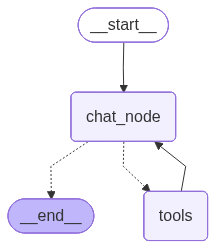

In [47]:
chatbot

In [48]:
result = chatbot.invoke(
    {
        "messages":[
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of k in kNN"
                )
            )
        ]
    }
)

In [49]:
print(result['messages'][-1].content)

The ideal value of k in kNN can be found by iterating through different values of k and evaluating the model's performance using a metric such as accuracy or mean squared error. The value of k that results in the best performance is selected as the ideal value. Additionally, techniques such as cross-validation can be used to evaluate the model's performance on unseen data and prevent overfitting.
